# Churn Model Interpretation & Action Strategy

이 노트북은 모델을 다시 학습하지 않는다. `05_churn_modeling_tuning_ensemble.ipynb`에서 저장한 test set risk score를 읽어 decile, lift, top-k targeting, 고위험 고객 프로파일, cluster × risk, 캠페인 액션 전략을 분석한다.

사용 파일:

- `outputs/churn_risk_scores_test.csv`
- `outputs/churn_model_final_result.csv`
- `outputs/churn_threshold_result.csv`

먼저 `05` 노트북의 **Risk Score 저장** 섹션을 실행해야 한다.

## 1. 라이브러리 로드

저장된 예측 결과를 분석하는 데 필요한 라이브러리만 사용한다. 모델 학습용 라이브러리는 필요하지 않다.

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), None)
if font_name:
    plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

## 2. 저장된 Risk Score 로드

`05`에서 저장한 고객별 이탈 확률을 불러온다. 이 파일에는 test 고객의 원본 피처, 실제 churn 여부, 최종 모델의 예측 확률, 선택 threshold 기준 예측값, cluster label이 포함된다.

In [2]:
output_dir = Path('../outputs') if Path('../outputs').exists() else Path('outputs')
risk_score_path = output_dir / 'churn_risk_scores_test.csv'
final_result_path = output_dir / 'churn_model_final_result.csv'
threshold_result_path = output_dir / 'churn_threshold_result.csv'

if not risk_score_path.exists():
    raise FileNotFoundError(
        f'{risk_score_path} not found. 먼저 05_churn_modeling_tuning_ensemble.ipynb의 Risk Score 저장 섹션을 실행하세요.'
    )

risk_df = pd.read_csv(risk_score_path)
final_result = pd.read_csv(final_result_path, index_col=0) if final_result_path.exists() else None
threshold_result = pd.read_csv(threshold_result_path) if threshold_result_path.exists() else None

risk_df = risk_df.sort_values('churn_probability', ascending=False).reset_index(drop=True)
risk_df['risk_rank'] = np.arange(1, len(risk_df) + 1)

print('Risk score path:', risk_score_path)
print('Shape:', risk_df.shape)
print('Final model:', risk_df['final_model'].iloc[0] if 'final_model' in risk_df.columns else 'unknown')
print('Selected threshold:', risk_df['selected_threshold'].iloc[0] if 'selected_threshold' in risk_df.columns else 'unknown')
print('Overall churn rate:', round(risk_df['actual_churn'].mean(), 4))
display(risk_df.head())

Risk score path: ../outputs/churn_risk_scores_test.csv
Shape: (10000, 26)
Final model: Stacking
Selected threshold: 0.6600000000000001
Overall churn rate: 0.2093


,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,...,app_rating,recommendation_click_rate,days_since_last_login,actual_churn,churn_probability,selected_threshold,selected_prediction,final_model,cluster,risk_rank
0,N23544,23,Male,Asia,Basic,Credit Card,Mobile,21,Horror,Afternoon,...,3,2,60,1,0.950002,0.66,1,Stacking,1,1
1,N31796,21,Male,South America,Basic,Gift Card,Laptop,26,Drama,Night,...,3,14,45,1,0.949849,0.66,1,Stacking,1,2
2,N18086,33,Female,North America,Basic,Credit Card,Mobile,7,Drama,Night,...,3,0,53,1,0.949826,0.66,1,Stacking,1,3
3,N34912,31,Male,Europe,Basic,Paypal,Mobile,9,Action,Morning,...,3,1,47,1,0.949816,0.66,1,Stacking,1,4
4,N08522,43,Male,North America,Basic,Debit Card,Mobile,31,Documentary,Afternoon,...,3,15,60,1,0.949784,0.66,1,Stacking,1,5


**로드 결과 해석**

- `06`은 모델을 다시 학습하지 않고, `05`에서 저장된 `outputs/churn_risk_scores_test.csv`를 사용한다.
- 로드된 test 결과는 10,000명, 26개 컬럼으로 구성되어 있다.
- 최종 모델은 `Stacking`, 선택 threshold는 0.66이다.
- 전체 test churn rate는 20.93%이며, 이 값이 이후 decile/lift 분석의 기준값이다.
- 예측 확률이 가장 높은 상위 고객들을 보면 `Basic` 요금제, Mobile/Laptop 사용, 긴 미접속 기간, 낮은 추천 클릭률 같은 패턴이 이미 나타난다.
- 모델 재학습이 없으므로 이 노트북은 빠르게 반복 실행할 수 있고, 분석/해석 및 캠페인 전략 수립에 집중할 수 있다.


## 3. 최종 모델과 Threshold 결과 확인

`05`에서 저장한 최종 후보 모델 성능표와 threshold별 trade-off를 확인한다.

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
Stacking,0.5,0.8341,0.572333,0.820354,0.674259,0.906675,0.764333
SoftVoting,0.5,0.8350,0.574504,0.816054,0.674299,0.905820,0.763909
XGBoost_RandomizedSearch,0.5,0.8345,0.573688,0.814620,0.673248,0.905117,0.763671
LogisticRegression_GridSearch,0.5,0.8332,0.570528,0.821309,0.673325,0.906560,0.763136
LightGBM_RandomizedSearch,0.5,0.8343,0.573649,0.811276,0.672076,0.902998,0.758715


,threshold,accuracy,precision,recall,f1
0,0.66,0.8609,0.642915,0.754419,0.694219


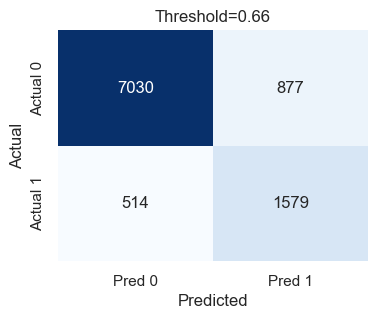

In [3]:
if final_result is not None:
    display(final_result.sort_values(['pr_auc', 'f1', 'recall'], ascending=False))
else:
    print('final_result file not found')

selected_threshold = float(risk_df['selected_threshold'].iloc[0]) if 'selected_threshold' in risk_df.columns else 0.5
selected_pred = (risk_df['churn_probability'] >= selected_threshold).astype(int)
threshold_metrics = {
    'threshold': selected_threshold,
    'accuracy': accuracy_score(risk_df['actual_churn'], selected_pred),
    'precision': precision_score(risk_df['actual_churn'], selected_pred, zero_division=0),
    'recall': recall_score(risk_df['actual_churn'], selected_pred, zero_division=0),
    'f1': f1_score(risk_df['actual_churn'], selected_pred, zero_division=0),
}
display(pd.DataFrame([threshold_metrics]))

cm = confusion_matrix(risk_df['actual_churn'], selected_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'], ax=ax)
ax.set_title(f'Threshold={selected_threshold:.2f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

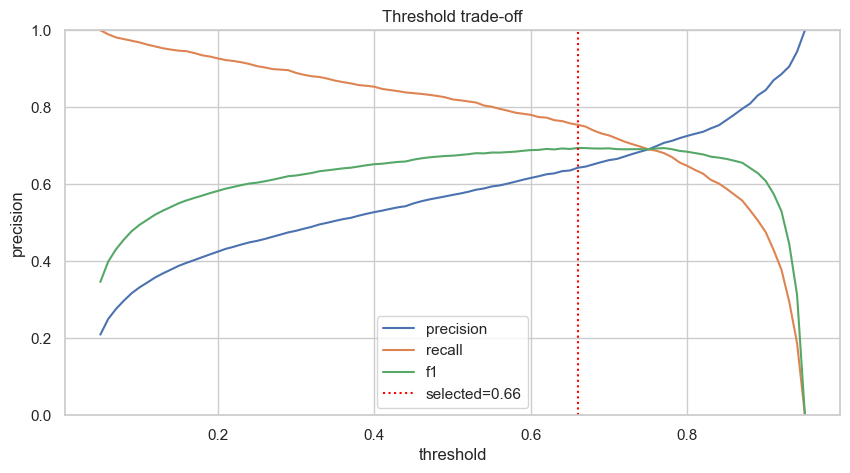

In [4]:
if threshold_result is not None:
    plt.figure(figsize=(10, 5))
    for metric in ['precision', 'recall', 'f1']:
        sns.lineplot(data=threshold_result, x='threshold', y=metric, label=metric)
    plt.axvline(selected_threshold, color='red', linestyle=':', label=f'selected={selected_threshold:.2f}')
    plt.ylim(0, 1)
    plt.title('Threshold trade-off')
    plt.legend()
    plt.show()
else:
    print('threshold_result file not found')

**Threshold 결과 해석**

- `05`의 최종 후보는 Stacking이며, 선택 threshold는 0.66이다.
- threshold 0.66에서는 accuracy 0.8609, precision 0.6429, recall 0.7544, f1 0.6942가 나온다.
- 이 값은 recall 0.70 이상을 유지하면서 f1이 가장 높은 균형점이다.
- threshold 0.5는 더 많은 이탈자를 잡는 대신 오탐이 많고, 0.66은 캠페인 대상 품질과 탐지율의 균형을 더 잘 맞춘다.
- 다만 retention 캠페인은 반드시 하나의 threshold로 끝낼 필요가 없다. 예산에 따라 상위 k% 고객을 순차적으로 타겟팅하는 ranking 방식이 더 실무적이다.


## 4. Decile Analysis

고객을 예측 이탈 확률 기준으로 10등분한다. Decile 1은 이탈 확률이 가장 높은 상위 10% 고객이다.

In [5]:
overall_churn_rate = risk_df['actual_churn'].mean()
total_churners = risk_df['actual_churn'].sum()

risk_df['decile'] = pd.qcut(risk_df['risk_rank'], q=10, labels=np.arange(1, 11)).astype(int)

decile_summary = risk_df.groupby('decile').agg(
    customers=('actual_churn', 'size'),
    churners=('actual_churn', 'sum'),
    churn_rate=('actual_churn', 'mean'),
    avg_predicted_probability=('churn_probability', 'mean'),
    min_predicted_probability=('churn_probability', 'min'),
    max_predicted_probability=('churn_probability', 'max'),
).reset_index()
decile_summary['lift'] = decile_summary['churn_rate'] / overall_churn_rate
decile_summary['cumulative_customers'] = decile_summary['customers'].cumsum()
decile_summary['cumulative_churners'] = decile_summary['churners'].cumsum()
decile_summary['cumulative_customer_pct'] = decile_summary['cumulative_customers'] / len(risk_df)
decile_summary['cumulative_churn_capture'] = decile_summary['cumulative_churners'] / total_churners

display(decile_summary)
print('Overall churn rate:', round(overall_churn_rate, 4))

,decile,customers,churners,churn_rate,avg_predicted_probability,min_predicted_probability,max_predicted_probability,lift,cumulative_customers,cumulative_churners,cumulative_customer_pct,cumulative_churn_capture
0,1,1000,876,0.876,0.935253,0.912998,0.950002,4.185380,1000,876,0.1,0.418538
1,2,1000,544,0.544,0.857136,0.773528,0.912996,2.599140,2000,1420,0.2,0.678452
2,3,1000,297,0.297,0.641815,0.500495,0.773400,1.419016,3000,1717,0.3,0.820354
3,4,1000,162,0.162,0.379294,0.281879,0.499971,0.774009,4000,1879,0.4,0.897754
4,5,1000,100,0.100,0.212204,0.160123,0.281655,0.477783,5000,1979,0.5,0.945533
5,6,1000,41,0.041,0.127597,0.103725,0.159986,0.195891,6000,2020,0.6,0.965122
6,7,1000,26,0.026,0.088850,0.077766,0.103720,0.124224,7000,2046,0.7,0.977544
7,8,1000,19,0.019,0.069409,0.062807,0.077750,0.090779,8000,2065,0.8,0.986622
8,9,1000,21,0.021,0.058244,0.054600,0.062795,0.100334,9000,2086,0.9,0.996656
9,10,1000,7,0.007,0.052210,0.049931,0.054586,0.033445,10000,2093,1.0,1.000000


Overall churn rate: 0.2093


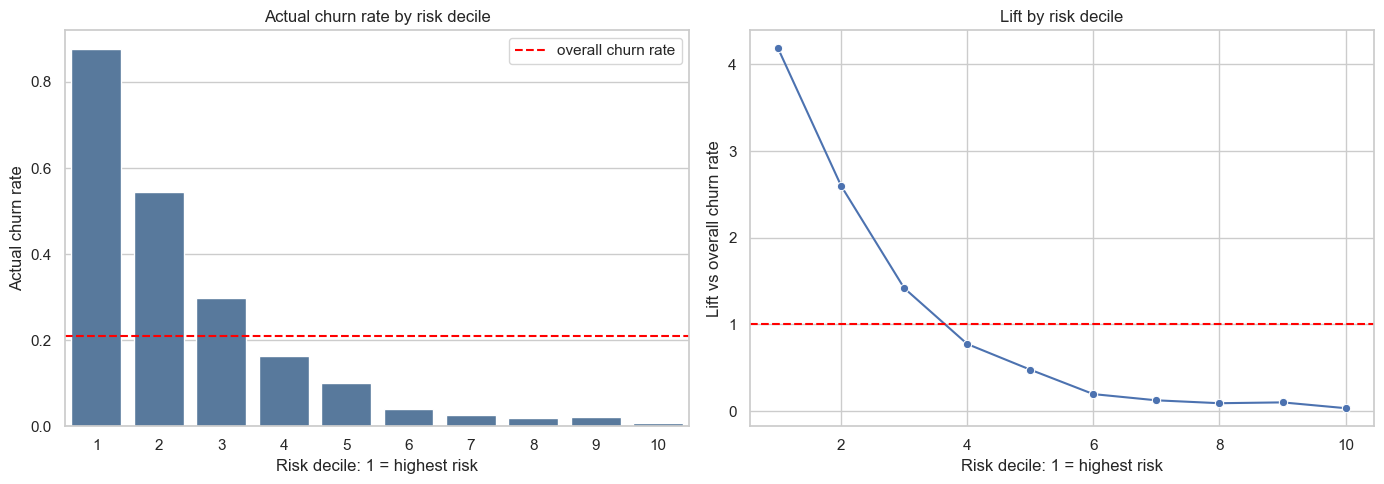

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=decile_summary, x='decile', y='churn_rate', ax=axes[0], color='#4C78A8')
axes[0].axhline(overall_churn_rate, color='red', linestyle='--', label='overall churn rate')
axes[0].set_title('Actual churn rate by risk decile')
axes[0].set_xlabel('Risk decile: 1 = highest risk')
axes[0].set_ylabel('Actual churn rate')
axes[0].legend()

sns.lineplot(data=decile_summary, x='decile', y='lift', marker='o', ax=axes[1])
axes[1].axhline(1, color='red', linestyle='--')
axes[1].set_title('Lift by risk decile')
axes[1].set_xlabel('Risk decile: 1 = highest risk')
axes[1].set_ylabel('Lift vs overall churn rate')

plt.tight_layout()
plt.show()

**Decile Analysis 해석**

- 전체 test churn rate는 20.93%다.
- 예측 이탈 확률 상위 10%인 Decile 1의 실제 churn rate는 87.6%다. 전체 평균 대비 lift는 4.19배다.
- Decile 2의 churn rate는 54.4%, lift는 2.60배다.
- Decile 3의 churn rate는 29.7%, lift는 1.42배로 여전히 평균보다 높다.
- Decile 4부터는 churn rate가 16.2%로 전체 평균보다 낮아지고, Decile 10은 0.7%까지 떨어진다.
- 상위 10% 고객만 타겟팅해도 전체 이탈자의 41.85%를 포착한다.
- 상위 20%는 전체 이탈자의 67.85%, 상위 30%는 82.04%를 포착한다.

이 결과는 모델이 이탈자를 상위 위험 구간에 매우 잘 모으고 있음을 보여준다. 따라서 이 모델은 0/1 classification 모델이라기보다 retention campaign 우선순위 모델로 해석하는 것이 더 적절하다.

## 5. Top-k Campaign Target Analysis

예산에 따라 상위 5%, 10%, 20%, 30% 고객을 타겟팅했을 때의 효율을 확인한다.

In [7]:
top_k_rows = []
for pct in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    n = int(np.ceil(len(risk_df) * pct))
    top_group = risk_df.head(n)
    churners = top_group['actual_churn'].sum()
    churn_rate = top_group['actual_churn'].mean()
    top_k_rows.append({
        'target_pct': pct,
        'target_customers': n,
        'captured_churners': churners,
        'target_churn_rate': churn_rate,
        'lift': churn_rate / overall_churn_rate,
        'cumulative_churn_capture': churners / total_churners,
    })

top_k_summary = pd.DataFrame(top_k_rows)
top_k_summary

,target_pct,target_customers,captured_churners,target_churn_rate,lift,cumulative_churn_capture
0,0.05,500,468,0.936000,4.472050,0.223602
1,0.10,1000,876,0.876000,4.185380,0.418538
2,0.20,2000,1420,0.710000,3.392260,0.678452
3,0.30,3000,1717,0.572333,2.734512,0.820354
4,0.40,4000,1879,0.469750,2.244386,0.897754
5,0.50,5000,1979,0.395800,1.891065,0.945533


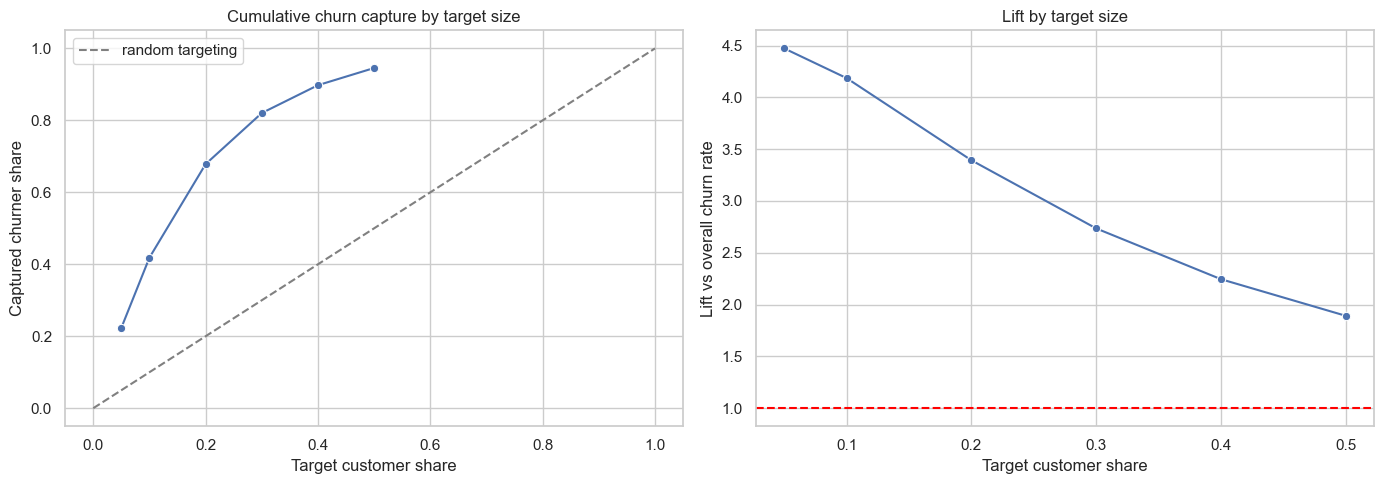

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=top_k_summary, x='target_pct', y='cumulative_churn_capture', marker='o', ax=axes[0])
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='random targeting')
axes[0].set_title('Cumulative churn capture by target size')
axes[0].set_xlabel('Target customer share')
axes[0].set_ylabel('Captured churner share')
axes[0].legend()

sns.lineplot(data=top_k_summary, x='target_pct', y='lift', marker='o', ax=axes[1])
axes[1].axhline(1, color='red', linestyle='--')
axes[1].set_title('Lift by target size')
axes[1].set_xlabel('Target customer share')
axes[1].set_ylabel('Lift vs overall churn rate')

plt.tight_layout()
plt.show()

**Top-k Campaign Target 해석**

- 상위 5% 고객 500명을 타겟팅하면 실제 churn rate는 93.6%이며, lift는 4.47배다.
- 상위 10% 고객 1,000명을 타겟팅하면 churn rate는 87.6%, lift는 4.19배이고, 전체 이탈자의 41.85%를 잡는다.
- 상위 20% 고객 2,000명을 타겟팅하면 churn rate는 71.0%, lift는 3.39배이고, 전체 이탈자의 67.85%를 잡는다.
- 상위 30% 고객 3,000명까지 확대하면 churn rate는 57.23%, lift는 2.73배이며, 전체 이탈자의 82.04%를 잡는다.
- 상위 40~50%까지 확대하면 포착률은 올라가지만 lift는 점점 낮아진다.

추천 전략은 예산에 따라 달라진다. 최소 예산이면 상위 5~10%, 균형 전략이면 상위 20%, 공격적 이탈 방어라면 상위 30%까지 타겟팅하는 것이 적절하다.

## 6. Risk Group 생성

상위 10%를 High, 다음 20%를 Medium, 나머지 70%를 Low risk로 구분한다.

In [9]:
high_cutoff = risk_df['churn_probability'].quantile(0.90)
medium_cutoff = risk_df['churn_probability'].quantile(0.70)

risk_df['risk_group'] = np.select(
    [
        risk_df['churn_probability'] >= high_cutoff,
        risk_df['churn_probability'] >= medium_cutoff,
    ],
    ['High', 'Medium'],
    default='Low',
)

risk_group_summary = risk_df.groupby('risk_group').agg(
    customers=('actual_churn', 'size'),
    churners=('actual_churn', 'sum'),
    churn_rate=('actual_churn', 'mean'),
    avg_predicted_probability=('churn_probability', 'mean'),
).reindex(['High', 'Medium', 'Low'])
risk_group_summary['lift'] = risk_group_summary['churn_rate'] / overall_churn_rate
risk_group_summary

,customers,churners,churn_rate,avg_predicted_probability,lift
risk_group,,,,,
High,1000,876,0.876000,0.935253,4.185380
Medium,2000,841,0.420500,0.749475,2.009078
Low,7000,376,0.053714,0.141115,0.256638


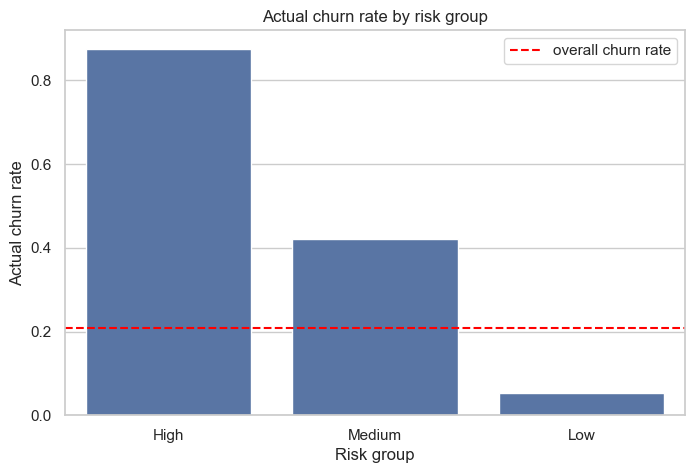

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=risk_group_summary.reset_index(), x='risk_group', y='churn_rate', order=['High', 'Medium', 'Low'])
plt.axhline(overall_churn_rate, color='red', linestyle='--', label='overall churn rate')
plt.title('Actual churn rate by risk group')
plt.xlabel('Risk group')
plt.ylabel('Actual churn rate')
plt.legend()
plt.show()

**Risk Group 해석**

- High risk는 예측 확률 상위 10% 고객이며, 실제 churn rate는 87.6%다. 전체 평균 대비 lift는 4.19배다.
- Medium risk는 그다음 20% 고객이며, 실제 churn rate는 42.05%다. 전체 평균 대비 lift는 2.01배다.
- Low risk는 나머지 70% 고객이며, 실제 churn rate는 5.37%에 불과하다.
- Low risk의 churn rate가 매우 낮기 때문에, 모델을 활용하면 불필요한 고비용 캠페인을 크게 줄일 수 있다.

## 7. 고위험 고객 프로파일링

High risk 고객군이 전체 고객 및 Low risk 고객과 어떤 차이를 보이는지 확인한다.

In [11]:
meta_cols = {
    'user_id', 'actual_churn', 'churn_probability', 'selected_threshold',
    'selected_prediction', 'final_model', 'cluster', 'risk_rank', 'decile', 'risk_group'
}
feature_cols = [col for col in risk_df.columns if col not in meta_cols]
numeric_features = risk_df[feature_cols].select_dtypes(include='number').columns.tolist()
categorical_features = risk_df[feature_cols].select_dtypes(include=['object', 'string', 'category']).columns.tolist()

high_risk_df = risk_df[risk_df['risk_group'] == 'High'].copy()
low_risk_df = risk_df[risk_df['risk_group'] == 'Low'].copy()

numeric_profile = pd.DataFrame({
    'overall_mean': risk_df[numeric_features].mean(),
    'high_risk_mean': high_risk_df[numeric_features].mean(),
    'low_risk_mean': low_risk_df[numeric_features].mean(),
})
numeric_profile['high_vs_overall_diff'] = numeric_profile['high_risk_mean'] - numeric_profile['overall_mean']
numeric_profile['high_vs_low_diff'] = numeric_profile['high_risk_mean'] - numeric_profile['low_risk_mean']
numeric_profile.sort_values('high_vs_overall_diff', key=lambda s: s.abs(), ascending=False)

,overall_mean,high_risk_mean,low_risk_mean,high_vs_overall_diff,high_vs_low_diff
avg_watch_time_minutes_per_week,276.3192,144.816,318.771000,-131.5032,-173.955000
days_since_last_login,12.1051,38.591,5.812429,26.4859,32.778571
recommendation_click_rate,38.5955,22.924,43.047857,-15.6715,-20.123857
account_age_months,44.8617,33.907,47.832286,-10.9547,-13.925286
completion_rate,72.9424,63.116,75.811857,-9.8264,-12.695857
age,39.2634,36.539,40.095286,-2.7244,-3.556286
watch_sessions_per_week,5.6733,3.288,6.431571,-2.3853,-3.143571
session_count,1.6269,1.148,1.792714,-0.4789,-0.644714
app_rating,3.9402,3.463,4.071286,-0.4772,-0.608286
avg_rating_given,3.8468,3.379,3.980000,-0.4678,-0.601000


In [12]:
def categorical_rate_diff(df_all, df_group, col, top_n=8):
    all_rate = df_all[col].value_counts(normalize=True)
    group_rate = df_group[col].value_counts(normalize=True)
    out = pd.DataFrame({
        'overall_ratio': all_rate,
        'high_risk_ratio': group_rate,
    }).fillna(0)
    out['diff'] = out['high_risk_ratio'] - out['overall_ratio']
    out['feature'] = col
    out['value'] = out.index
    return out.reindex(out['diff'].abs().sort_values(ascending=False).index).head(top_n)

cat_profile = pd.concat([
    categorical_rate_diff(risk_df, high_risk_df, col, top_n=5)
    for col in categorical_features
], ignore_index=True)
cat_profile.sort_values('diff', key=lambda s: s.abs(), ascending=False).head(30)

,overall_ratio,high_risk_ratio,diff,feature,value
7,0.3783,0.727,0.3487,subscription_type,Basic
14,0.4842,0.181,-0.3032,primary_device,Smart TV
8,0.2631,0.031,-0.2321,subscription_type,Premium
15,0.2995,0.525,0.2255,primary_device,Mobile
9,0.3586,0.242,-0.1166,subscription_type,Standard
27,0.3470,0.233,-0.1140,recommendation_source,Algorithm
28,0.0972,0.206,0.1088,recommendation_source,Ads
10,0.4356,0.331,-0.1046,payment_method,Credit Card
11,0.0772,0.144,0.0668,payment_method,Gift Card
16,0.1367,0.196,0.0593,primary_device,Laptop


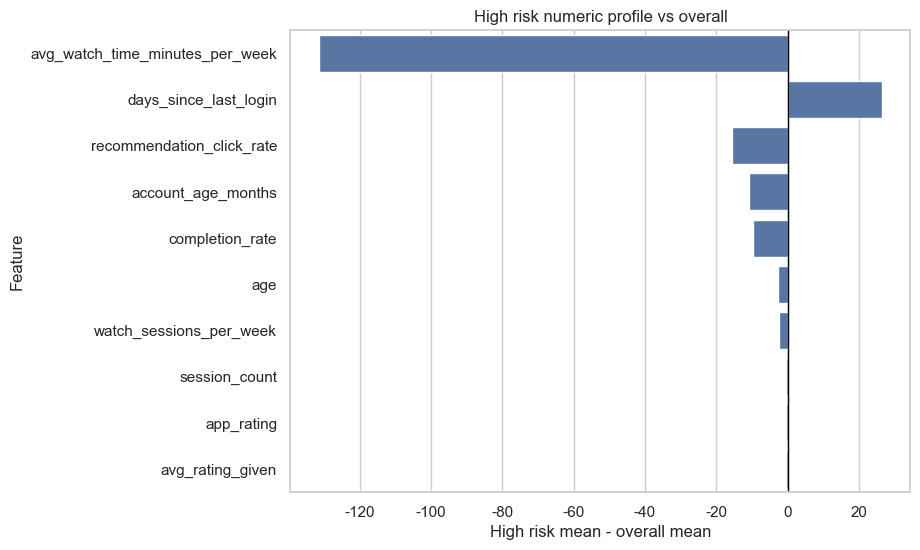

In [13]:
plt.figure(figsize=(8, 6))
plot_numeric = numeric_profile.assign(abs_diff=numeric_profile['high_vs_overall_diff'].abs()).sort_values('abs_diff', ascending=False).head(10)
sns.barplot(data=plot_numeric.reset_index(), x='high_vs_overall_diff', y='index')
plt.axvline(0, color='black', linewidth=1)
plt.title('High risk numeric profile vs overall')
plt.xlabel('High risk mean - overall mean')
plt.ylabel('Feature')
plt.show()

**고위험 고객 프로파일 해석**

High risk 고객은 전체 고객과 비교해 행동 지표가 뚜렷하게 다르다.

- 주간 평균 시청 시간은 전체 평균보다 크게 낮다.
- 마지막 로그인 후 경과일은 크게 높다.
- 추천 클릭률, completion rate, app rating, 주간 시청 세션 수가 모두 낮다.
- Basic 요금제 비율과 Mobile 사용 비율이 높고, Premium 및 Smart TV 비율은 낮다.
- 추천 경로 중 Ads 비율은 높고 Algorithm 비율은 낮다.

즉, High risk 고객은 최근 접속이 뜸하고, 시청량과 추천 반응이 낮으며, Basic 요금제와 Mobile 중심 사용 패턴을 보이는 고객군이다. 액션은 복귀 유도, 모바일 친화 추천, 짧은 콘텐츠 큐레이션, 요금제 혜택 제안을 중심으로 설계하는 것이 적절하다.

## 8. Cluster × Risk 결합 분석

`05`에서 train 데이터로만 fit한 KMeans cluster label을 test risk score와 함께 저장했다. 여기서는 cluster와 risk group을 결합해 세그먼트별 위험도를 본다.

In [14]:
if 'cluster' not in risk_df.columns:
    raise KeyError('cluster column not found. 05의 Risk Score 저장 셀에서 cluster label을 함께 저장했는지 확인하세요.')

cluster_risk_summary = risk_df.groupby(['cluster', 'risk_group']).agg(
    customers=('actual_churn', 'size'),
    churners=('actual_churn', 'sum'),
    churn_rate=('actual_churn', 'mean'),
    avg_predicted_probability=('churn_probability', 'mean'),
).reset_index()
cluster_risk_summary['lift'] = cluster_risk_summary['churn_rate'] / overall_churn_rate
cluster_risk_summary.sort_values(['cluster', 'churn_rate'], ascending=[True, False])

,cluster,risk_group,customers,churners,churn_rate,avg_predicted_probability,lift
0,0,High,2,2,1.000000,0.929666,4.777831
2,0,Medium,31,11,0.354839,0.670555,1.695359
1,0,Low,1947,46,0.023626,0.075491,0.112881
3,1,High,989,869,0.878665,0.935362,4.198114
5,1,Medium,1380,636,0.460870,0.781679,2.201957
4,1,Low,542,61,0.112546,0.296156,0.537726
6,2,High,9,5,0.555556,0.924527,2.654350
8,2,Medium,589,194,0.329372,0.678178,1.573683
7,2,Low,4511,269,0.059632,0.150811,0.284912


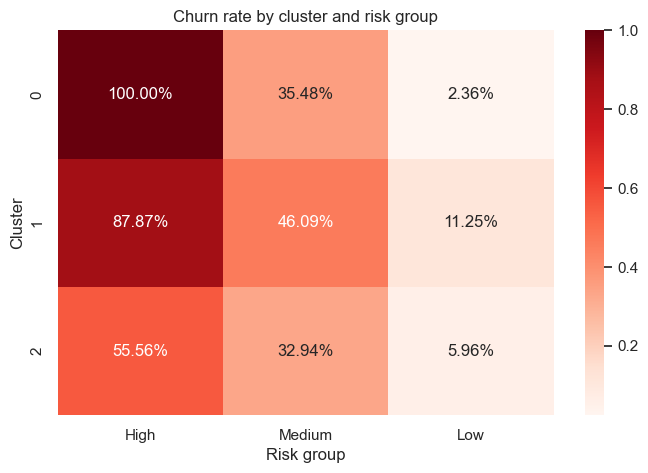

In [15]:
pivot_cluster_risk = cluster_risk_summary.pivot(index='cluster', columns='risk_group', values='churn_rate')
ordered_cols = [col for col in ['High', 'Medium', 'Low'] if col in pivot_cluster_risk.columns]
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_cluster_risk[ordered_cols], annot=True, fmt='.2%', cmap='Reds')
plt.title('Churn rate by cluster and risk group')
plt.xlabel('Risk group')
plt.ylabel('Cluster')
plt.show()

**Cluster × Risk 결합 해석**

- cluster와 risk group을 결합해 보면, High risk 고객 대부분은 cluster 1에 집중되어 있다. cluster 1 High risk는 989명이고, 이 중 869명이 실제 churn으로 churn rate는 87.87%다.
- cluster 0 High risk는 2명, cluster 2 High risk는 9명뿐이다. 각각 churn rate가 100.0%, 55.56%로 보이지만 표본 수가 너무 작아 이 비율 자체를 강하게 해석하면 안 된다.
- Medium risk에서는 cluster 1의 churn rate가 46.09%로 가장 높고, cluster 0은 35.48%, cluster 2는 32.94%다.
- Low risk는 전체적으로 낮지만 cluster별 차이가 있다. cluster 0 Low는 2.36%로 매우 낮고, cluster 1 Low는 11.25%로 Low group 중에서는 상대적으로 높다.
- 이 결과는 캠페인 우선순위는 risk score로 정하고, cluster는 메시지/혜택을 세분화하는 보조 기준으로 쓰는 것이 적절하다는 점을 보여준다.
- 특히 cluster 1은 High/Medium risk 고객이 많이 모여 있으므로 retention action의 핵심 세그먼트로 볼 수 있다.


## 9. Campaign Action Matrix

모델 결과를 retention action으로 번역한다.

In [16]:
action_matrix = pd.DataFrame([
    {
        'risk_group': 'High',
        'priority': 1,
        'recommended_action': '즉시 개입: 개인화 복귀 메시지, 할인/혜택, 최근 관심 장르 기반 추천',
        'rationale': '실제 churn rate와 lift가 가장 높은 그룹이므로 캠페인 우선순위가 가장 높다.',
    },
    {
        'risk_group': 'Medium',
        'priority': 2,
        'recommended_action': '가벼운 개입: 추천 콘텐츠 알림, 시청 이어보기 유도, 앱 경험 개선 메시지',
        'rationale': 'High보다 위험은 낮지만 전체 평균보다 높아 저비용 캠페인 대상으로 적합하다.',
    },
    {
        'risk_group': 'Low',
        'priority': 3,
        'recommended_action': '유지 관리: 일반 추천, 충성 고객 혜택, 만족도 유지',
        'rationale': '이탈 위험이 낮으므로 고비용 할인 캠페인보다 관계 유지 중심이 적합하다.',
    },
])
action_matrix

,risk_group,priority,recommended_action,rationale
0,High,1,"즉시 개입: 개인화 복귀 메시지, 할인/혜택, 최근 관심 장르 기반 추천",실제 churn rate와 lift가 가장 높은 그룹이므로 캠페인 우선순위가 가장 높다.
1,Medium,2,"가벼운 개입: 추천 콘텐츠 알림, 시청 이어보기 유도, 앱 경험 개선 메시지",High보다 위험은 낮지만 전체 평균보다 높아 저비용 캠페인 대상으로 적합하다.
2,Low,3,"유지 관리: 일반 추천, 충성 고객 혜택, 만족도 유지",이탈 위험이 낮으므로 고비용 할인 캠페인보다 관계 유지 중심이 적합하다.


**Campaign Action Matrix 해석**

- High risk는 churn rate 87.6%로 즉시 개입 대상이다. 개인화 복귀 메시지, 할인/혜택, 최근 관심 장르 기반 추천처럼 강한 액션을 적용할 수 있다.
- Medium risk는 churn rate 42.05%로 전체 평균의 약 2배다. 고비용 할인보다는 추천 콘텐츠 알림, 이어보기 유도, 앱 경험 개선 메시지 같은 저비용 캠페인에 적합하다.
- Low risk는 churn rate 5.37%로 낮기 때문에 고비용 캠페인 대상에서 제외하는 것이 효율적이다.
- 최소 예산이면 상위 5~10%, 균형 전략이면 상위 20%, 공격적 이탈 방어라면 상위 30%까지 타겟팅하는 전략이 적절하다.
- cluster를 함께 활용한다면, cluster 1의 High/Medium risk 고객을 우선 액션 대상으로 두고 메시지를 세분화하는 방식이 좋다.


## 10. 최종 정리

이 노트북의 핵심 결론은 “모델을 다시 학습하지 않고도, 저장된 risk score만으로 충분히 강한 비즈니스 해석을 만들 수 있다”는 것이다.

최종 모델은 `05`에서 학습한 Stacking이며, `06`은 이 모델의 test 예측 결과를 활용해 campaign targeting 관점의 분석을 수행했다. threshold 0.66 기준으로 precision 0.6429, recall 0.7544, f1 0.6942를 얻었다.

가장 중요한 결과는 decile과 top-k 분석이다. 전체 test churn rate는 약 20.93%인데, 이탈 확률 상위 10% 고객의 실제 churn rate는 87.6%였다. 이는 평균 대비 4.19배 높은 위험도다. 상위 20% 고객만 타겟팅해도 전체 이탈자의 67.85%를 포착하고, 상위 30%까지 확대하면 전체 이탈자의 82.04%를 포착한다.

고위험 고객의 행동 특성도 명확하다. High risk 고객은 주간 시청 시간이 낮고, 마지막 로그인 후 경과일이 길며, 추천 클릭률과 completion rate가 낮다. 범주형으로는 Basic 요금제와 Mobile 사용 비중이 높고, Premium 및 Smart TV 비중은 낮다.

cluster 결합 분석에서는 High risk 고객 대부분이 cluster 1에 집중되어 있었다. 따라서 우선순위는 risk score로 정하되, cluster 1의 High/Medium risk 고객을 핵심 액션 세그먼트로 보고 메시지와 혜택을 세분화하는 전략이 적절하다.

따라서 이 모델은 완벽한 churn classification 모델이라기보다, retention campaign의 우선순위와 예산 배분을 지원하는 risk ranking 모델로 활용하는 것이 가장 타당하다.
